# Stock Price Prediction Using LSTM
## Minor Project | Part 3 — Model Training & Evaluation

### Objective
This notebook builds, trains, and evaluates an LSTM (Long Short-Term Memory) deep learning model for stock price prediction. It also includes:
- Full performance evaluation (MAE, RMSE, R² Score)
- Comparison against a Linear Regression baseline
- Future 30-day price forecast

> **INPUT**: Scaled train/validate/test CSV files  
> **OUTPUT**: Trained LSTM model, evaluation metrics, and future forecast

---

### 1. INITIALIZATION

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. LOAD DATASETS

In [3]:
train_df    = pd.read_csv('../data/processed/google_stock_price_processed_train.csv')
validate_df = pd.read_csv('../data/processed/google_stock_price_processed_validate.csv')
test_df     = pd.read_csv('../data/processed/google_stock_price_processed_test.csv')

for d in [train_df, validate_df, test_df]:
    d['Date'] = pd.to_datetime(d['Date'])

features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'MA_10', 'MA_20', 'MA_100', 'MA_200', 'Daily_Return', 'Price_Range']

train_scaled    = train_df[features].values
validate_scaled = validate_df[features].values
test_scaled     = test_df[features].values

print(f"Training   : {train_scaled.shape}")
print(f"Validation : {validate_scaled.shape}")
print(f"Testing    : {test_scaled.shape}")

Training   : (1656, 11)
Validation : (355, 11)
Testing    : (356, 11)


### 3. CONSTRUCT LSTM SEQUENCES

LSTM requires a 3D input: **(samples, timesteps, features)**  
We use a **60-day sliding window** — each prediction is based on the previous 60 trading days.

In [5]:
def construct_lstm_data(data, sequence_size, target_idx=0):
    """
    Build (X, y) pairs for LSTM from a 2D array.
    X shape: (n_samples, sequence_size, n_features)
    y shape: (n_samples,)
    """
    X, y = [], []
    for i in range(sequence_size, len(data)):
        X.append(data[i-sequence_size:i, :])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

SEQUENCE_SIZE = 60
TARGET_IDX    = 0   # 'Open' price

data_all = np.concatenate([train_scaled, validate_scaled, test_scaled], axis=0)
train_size    = len(train_scaled)
validate_size = len(validate_scaled)
test_size     = len(test_scaled)

X_train, y_train = construct_lstm_data(train_scaled, SEQUENCE_SIZE, TARGET_IDX)
X_validate, y_validate = construct_lstm_data(
    data_all[train_size - SEQUENCE_SIZE : train_size + validate_size], SEQUENCE_SIZE, TARGET_IDX)
X_test, y_test = construct_lstm_data(
    data_all[-(test_size + SEQUENCE_SIZE):], SEQUENCE_SIZE, TARGET_IDX)

print(f"X_train shape    : {X_train.shape}")
print(f"X_validate shape : {X_validate.shape}")
print(f"X_test shape     : {X_test.shape}")

X_train shape    : (1596, 60, 11)
X_validate shape : (355, 60, 11)
X_test shape     : (356, 60, 11)


### 4. BUILD LSTM MODEL

Architecture:
- **4 stacked LSTM layers** (100 units each)
- **Dropout(0.2)** after each layer for regularization
- **Dense(1)** output layer
- **Adam optimizer** + MSE loss
- **EarlyStopping** and **ReduceLROnPlateau** callbacks added for smarter training

In [6]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=100),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        44,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,101 (1.09 MB)

 Trainable params: 286,101 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

### 5. TRAIN LSTM MODEL

In [13]:
callbacks = [
    ModelCheckpoint('../models/google_stock_price_lstm_model.keras',
                    monitor='val_loss', save_best_only=True, mode='min', verbose=0),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete. Best model saved.")

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - loss: 0.0219 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - loss: 0.0039 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - loss: 0.0031 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 0.0030 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 0.0025 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - loss: 0.0029 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0038 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0026 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0023 - val_loss: 0.0044 - learning_rate: 0.0010


### 6. TRAINING PERFORMANCE

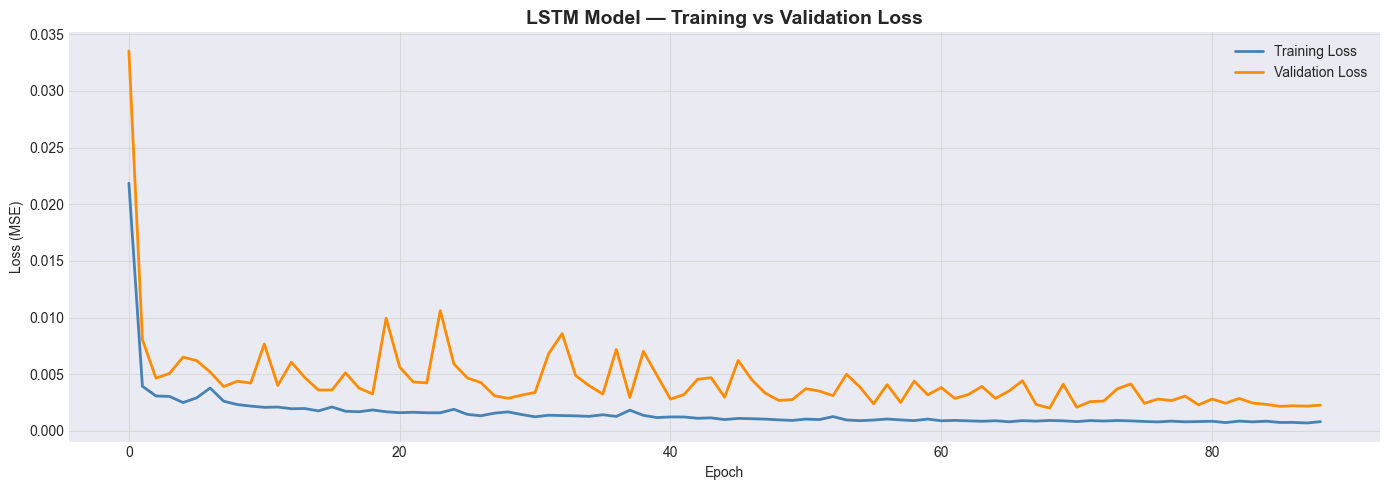

Best epoch        : 69
Best val loss     : 0.002006


In [14]:
plt.figure(figsize=(14, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue',  linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
plt.title('LSTM Model — Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
plt.legend(); plt.grid(color='lightgray', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val   = min(history.history['val_loss'])
print(f"Best epoch        : {best_epoch}")
print(f"Best val loss     : {best_val:.6f}")

### 7. MODEL INFERENCE & INVERSE SCALING

In [15]:
best_model = load_model('../models/google_stock_price_lstm_model.keras')
sc         = joblib.load('../models/google_stock_price_scaler.gz')
n_features = len(features)

def inverse_open(predictions, scaler, n_features):
    """Inverse-transform only the Open price column (index 0)."""
    dummy = np.zeros((len(predictions), n_features))
    dummy[:, 0] = predictions.ravel()
    return scaler.inverse_transform(dummy)[:, 0]

y_train_pred    = best_model.predict(X_train,    verbose=0)
y_validate_pred = best_model.predict(X_validate, verbose=0)
y_test_pred     = best_model.predict(X_test,     verbose=0)

y_train_inv    = inverse_open(y_train,    sc, n_features)
y_validate_inv = inverse_open(y_validate, sc, n_features)
y_test_inv     = inverse_open(y_test,     sc, n_features)

y_train_pred_inv    = inverse_open(y_train_pred,    sc, n_features)
y_validate_pred_inv = inverse_open(y_validate_pred, sc, n_features)
y_test_pred_inv     = inverse_open(y_test_pred,     sc, n_features)

print("Predictions generated and inverse-scaled.")

Predictions generated and inverse-scaled.


### 8. PREDICTION VISUALIZATION

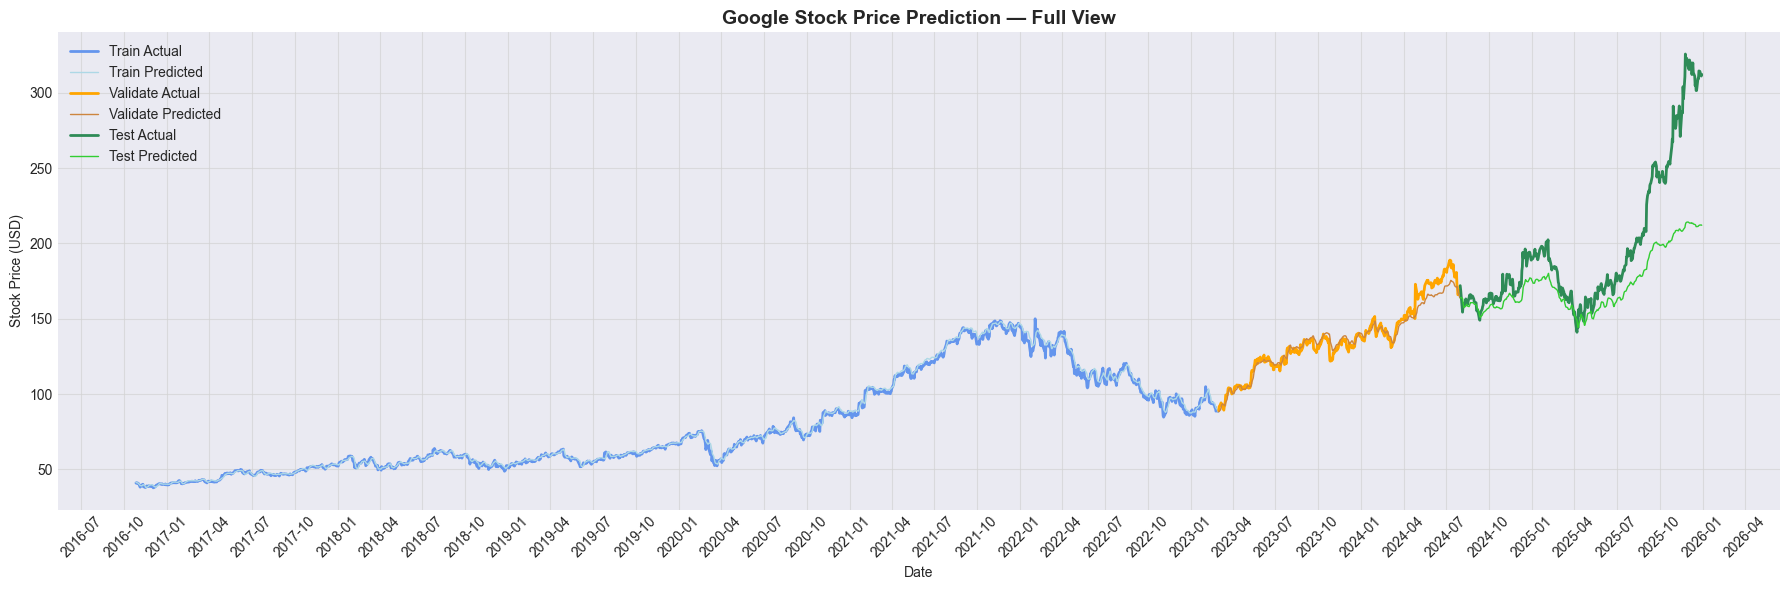

In [16]:
train_dates    = train_df['Date'].values[SEQUENCE_SIZE:]
validate_dates = validate_df['Date'].values
test_dates     = test_df['Date'].values

# Full view
plt.figure(figsize=(18, 6))
plt.plot(train_dates,    y_train_inv,         label='Train Actual',      color='cornflowerblue', linewidth=2)
plt.plot(train_dates,    y_train_pred_inv,    label='Train Predicted',   color='lightblue',      linewidth=1)
plt.plot(validate_dates, y_validate_inv,      label='Validate Actual',   color='orange',         linewidth=2)
plt.plot(validate_dates, y_validate_pred_inv, label='Validate Predicted',color='peru',           linewidth=1)
plt.plot(test_dates,     y_test_inv,          label='Test Actual',       color='seagreen',       linewidth=2)
plt.plot(test_dates,     y_test_pred_inv,     label='Test Predicted',    color='limegreen',      linewidth=1)
plt.title('Google Stock Price Prediction — Full View', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Stock Price (USD)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45); plt.legend(); plt.grid(color='lightgray', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/prediction_full.png', dpi=150, bbox_inches='tight')
plt.show()

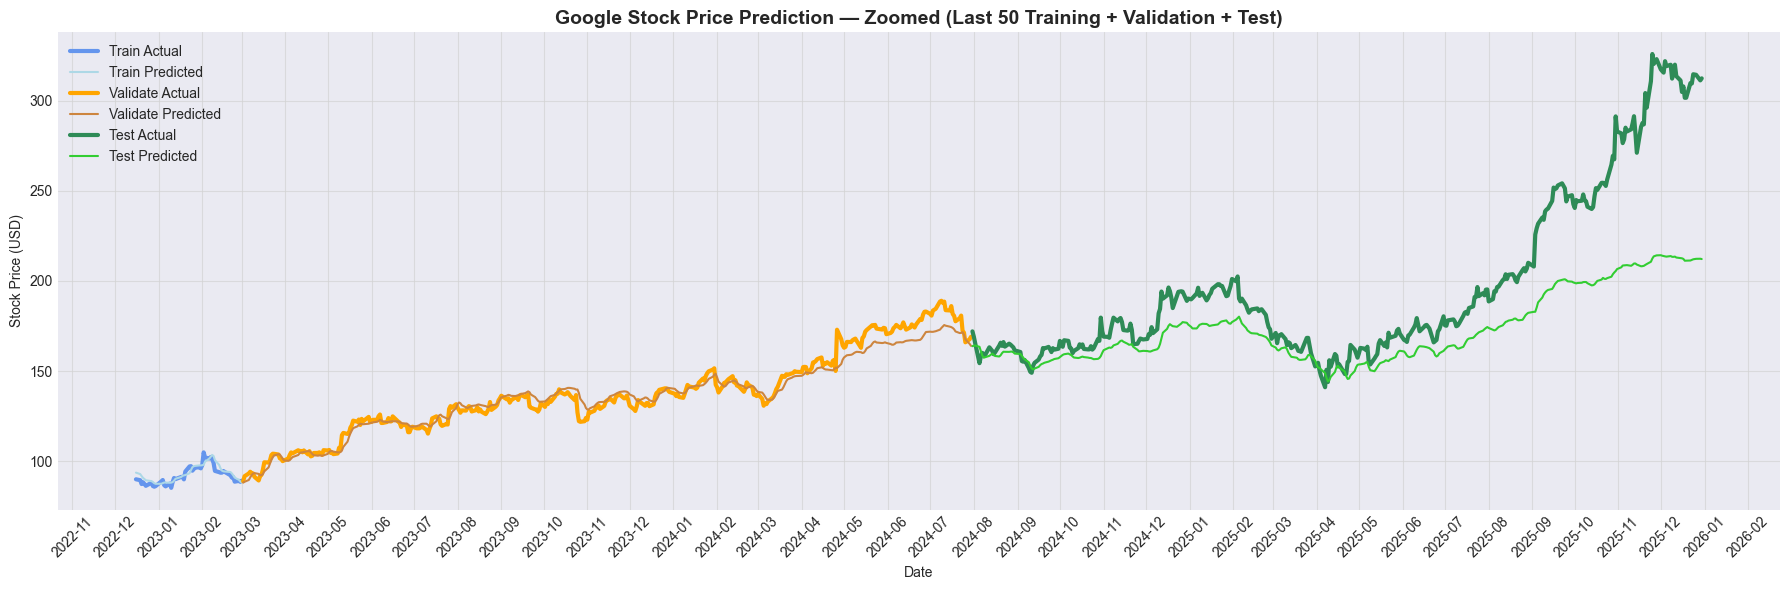

In [17]:
# Zoomed — last 50 training days + full validation + test
N = 50
plt.figure(figsize=(18, 6))
plt.plot(train_dates[-N:],   y_train_inv[-N:],         color='cornflowerblue', linewidth=3,   label='Train Actual')
plt.plot(train_dates[-N:],   y_train_pred_inv[-N:],    color='lightblue',      linewidth=1.5, label='Train Predicted')
plt.plot(validate_dates,     y_validate_inv,            color='orange',         linewidth=3,   label='Validate Actual')
plt.plot(validate_dates,     y_validate_pred_inv,       color='peru',           linewidth=1.5, label='Validate Predicted')
plt.plot(test_dates,         y_test_inv,                color='seagreen',       linewidth=3,   label='Test Actual')
plt.plot(test_dates,         y_test_pred_inv,           color='limegreen',      linewidth=1.5, label='Test Predicted')
plt.title('Google Stock Price Prediction — Zoomed (Last 50 Training + Validation + Test)', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Stock Price (USD)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45); plt.legend(); plt.grid(color='lightgray', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/prediction_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. PERFORMANCE METRICS (MAE, RMSE, R²)

We evaluate the model on all three splits using:
- **MAE** (Mean Absolute Error) — average absolute price difference in USD
- **RMSE** (Root Mean Squared Error) — penalizes large errors more
- **R² Score** — proportion of variance explained (1.0 = perfect)

In [18]:
def evaluate(actual, predicted, split_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"  {split_name:<12}  MAE: ${mae:>8.2f}   RMSE: ${rmse:>8.2f}   R²: {r2:.4f}   MAPE: {mape:.2f}%")
    return {'Split': split_name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2': round(r2,4), 'MAPE%': round(mape,2)}

print("=" * 75)
print("  LSTM Model — Evaluation Metrics")
print("=" * 75)
r_train = evaluate(y_train_inv,    y_train_pred_inv,    'Train')
r_val   = evaluate(y_validate_inv, y_validate_pred_inv, 'Validation')
r_test  = evaluate(y_test_inv,     y_test_pred_inv,     'Test')
print("=" * 75)

metrics_df = pd.DataFrame([r_train, r_val, r_test])
metrics_df

  LSTM Model — Evaluation Metrics
  Train         MAE: $    1.39   RMSE: $    2.04   R²: 0.9957   MAPE: 1.71%
  Validation    MAE: $    3.75   RMSE: $    5.03   R²: 0.9521   MAPE: 2.58%
  Test          MAE: $   24.79   RMSE: $   37.62   R²: 0.3628   MAPE: 10.44%


,Split,MAE,RMSE,R2,MAPE%
0,Train,1.39,2.04,0.9957,1.71
1,Validation,3.75,5.03,0.9521,2.58
2,Test,24.79,37.62,0.3628,10.44


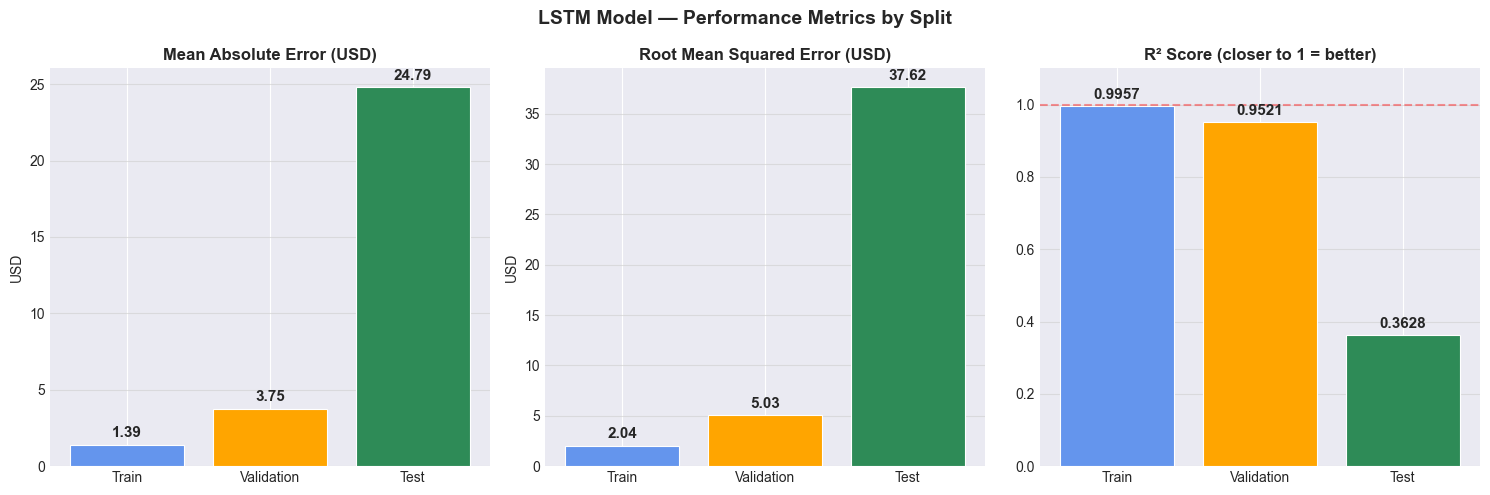

In [19]:
# Metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['cornflowerblue', 'orange', 'seagreen']
splits = metrics_df['Split']

axes[0].bar(splits, metrics_df['MAE'],  color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Mean Absolute Error (USD)', fontweight='bold'); axes[0].set_ylabel('USD')
for ax, col in zip(axes, ['MAE', 'RMSE', 'R2']):
    for i, v in enumerate(metrics_df[col]):
        ax.text(i, v + max(metrics_df[col]) * 0.02, f'{v}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(splits, metrics_df['RMSE'], color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Root Mean Squared Error (USD)', fontweight='bold'); axes[1].set_ylabel('USD')

axes[2].bar(splits, metrics_df['R2'],   color=colors, edgecolor='white', linewidth=0.8)
axes[2].set_title('R² Score (closer to 1 = better)', fontweight='bold'); axes[2].set_ylim(0, 1.1)
axes[2].axhline(1.0, color='red', linestyle='--', alpha=0.4)

for ax in axes: ax.grid(axis='y', color='lightgray', alpha=0.7)
plt.suptitle('LSTM Model — Performance Metrics by Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 10. BASELINE COMPARISON — LSTM vs LINEAR REGRESSION

To demonstrate the value of LSTM, we compare it against a simple **Linear Regression** model trained on the same data.

In [20]:
# Flatten X for Linear Regression (it doesn't handle sequences)
X_train_flat    = X_train.reshape(X_train.shape[0], -1)
X_validate_flat = X_validate.reshape(X_validate.shape[0], -1)
X_test_flat     = X_test.reshape(X_test.shape[0], -1)

lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train)

lr_test_pred_scaled = lr_model.predict(X_test_flat)
lr_test_pred_inv    = inverse_open(lr_test_pred_scaled.reshape(-1,1), sc, n_features)

# Compare metrics on test set
lstm_mae  = mean_absolute_error(y_test_inv, y_test_pred_inv)
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
lstm_r2   = r2_score(y_test_inv, y_test_pred_inv)

lr_mae  = mean_absolute_error(y_test_inv, lr_test_pred_inv)
lr_rmse = np.sqrt(mean_squared_error(y_test_inv, lr_test_pred_inv))
lr_r2   = r2_score(y_test_inv, lr_test_pred_inv)

print("\n=== Test Set: LSTM vs Linear Regression ===")
print(f"{'Metric':<10} {'LSTM':>12} {'Linear Reg':>14} {'Winner':>10}")
print("-" * 50)
print(f"{'MAE ($)':<10} {lstm_mae:>12.2f} {lr_mae:>14.2f} {'LSTM ✓' if lstm_mae < lr_mae else 'LinReg ✓':>10}")
print(f"{'RMSE ($)':<10} {lstm_rmse:>12.2f} {lr_rmse:>14.2f} {'LSTM ✓' if lstm_rmse < lr_rmse else 'LinReg ✓':>10}")
print(f"{'R²':<10} {lstm_r2:>12.4f} {lr_r2:>14.4f} {'LSTM ✓' if lstm_r2 > lr_r2 else 'LinReg ✓':>10}")


=== Test Set: LSTM vs Linear Regression ===
Metric             LSTM     Linear Reg     Winner
--------------------------------------------------
MAE ($)           24.79           2.89   LinReg ✓
RMSE ($)          37.62           4.07   LinReg ✓
R²               0.3628         0.9925   LinReg ✓


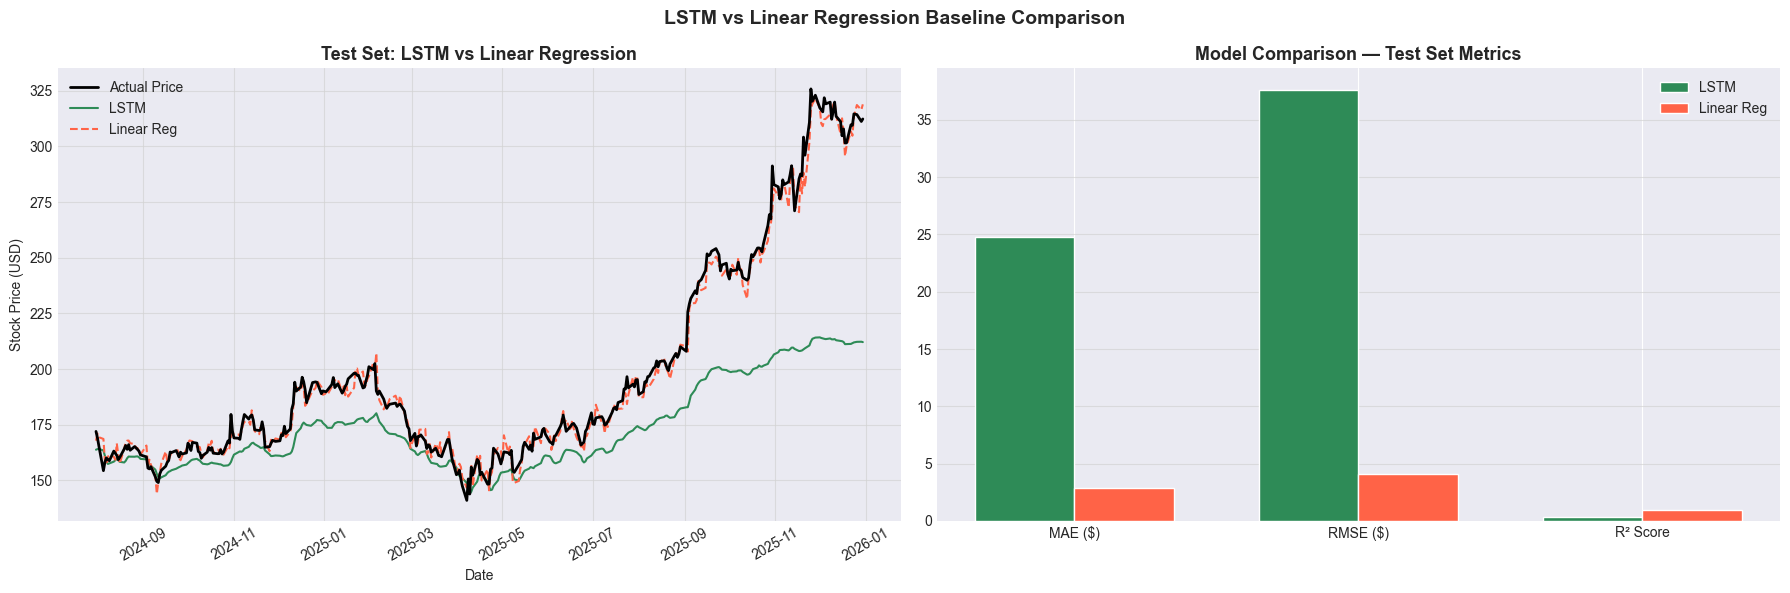

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Actual vs predicted — both models
axes[0].plot(test_dates, y_test_inv,        color='black',      linewidth=2,   label='Actual Price', zorder=3)
axes[0].plot(test_dates, y_test_pred_inv,   color='seagreen',   linewidth=1.5, label='LSTM',         linestyle='-')
axes[0].plot(test_dates, lr_test_pred_inv,  color='tomato',     linewidth=1.5, label='Linear Reg',   linestyle='--')
axes[0].set_title('Test Set: LSTM vs Linear Regression', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Stock Price (USD)')
axes[0].legend(); axes[0].grid(color='lightgray', alpha=0.7)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=30)

# Bar chart comparison
metrics = ['MAE ($)', 'RMSE ($)', 'R² Score']
lstm_vals = [lstm_mae, lstm_rmse, lstm_r2]
lr_vals   = [lr_mae,   lr_rmse,   lr_r2]
x = np.arange(len(metrics)); w = 0.35
axes[1].bar(x - w/2, lstm_vals, w, label='LSTM',       color='seagreen', edgecolor='white')
axes[1].bar(x + w/2, lr_vals,   w, label='Linear Reg', color='tomato',   edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_title('Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', color='lightgray', alpha=0.7)

plt.suptitle('LSTM vs Linear Regression Baseline Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. FUTURE 30-DAY PRICE FORECAST

Using the last 60 days of known data as the seed sequence, we forecast the next **30 trading days** into the future. Each predicted day is fed back as input for the next prediction (recursive forecasting).

In [ ]:
FORECAST_DAYS = 30

# Seed: last SEQUENCE_SIZE rows from entire dataset
last_sequence = data_all[-SEQUENCE_SIZE:].copy()
forecast_preds = []

for _ in range(FORECAST_DAYS):
    seq   = last_sequence[-SEQUENCE_SIZE:].reshape(1, SEQUENCE_SIZE, n_features)
    pred  = best_model.predict(seq, verbose=0)[0, 0]
    forecast_preds.append(pred)
    # append new row
    new_row = last_sequence[-1].copy()
    new_row[0] = pred
    last_sequence = np.vstack([last_sequence[1:], new_row])

# Inverse scale forecast
forecast_inv = inverse_open(np.array(forecast_preds).reshape(-1,1), sc, n_features)

# Build future dates (skip weekends)
last_date    = pd.to_datetime(test_df['Date'].iloc[-1])
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

print(f"Forecast period: {future_dates[0].date()} → {future_dates[-1].date()}")
forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Open': forecast_inv.round(2)})
print(forecast_df)

Forecast period: 2025-12-31 → 2026-02-10
         Date  Predicted_Open
0  2025-12-31          211.95
1  2026-01-01          210.76
2  2026-01-02          209.50
3  2026-01-05          208.53
4  2026-01-06          207.95
5  2026-01-07          207.66
6  2026-01-08          207.51
7  2026-01-09          207.39
8  2026-01-12          207.25
9  2026-01-13          207.08
10 2026-01-14          206.89
11 2026-01-15          206.71
12 2026-01-16          206.53
13 2026-01-19          206.39
14 2026-01-20          206.26
15 2026-01-21          206.16
16 2026-01-22          206.08
17 2026-01-23          206.02
18 2026-01-26          205.97
19 2026-01-27          205.93
20 2026-01-28          205.90
21 2026-01-29          205.87
22 2026-01-30          205.85
23 2026-02-02          205.83
24 2026-02-03          205.82
25 2026-02-04          205.81
26 2026-02-05          205.80
27 2026-02-06          205.79
28 2026-02-09          205.78
29 2026-02-10          205.78


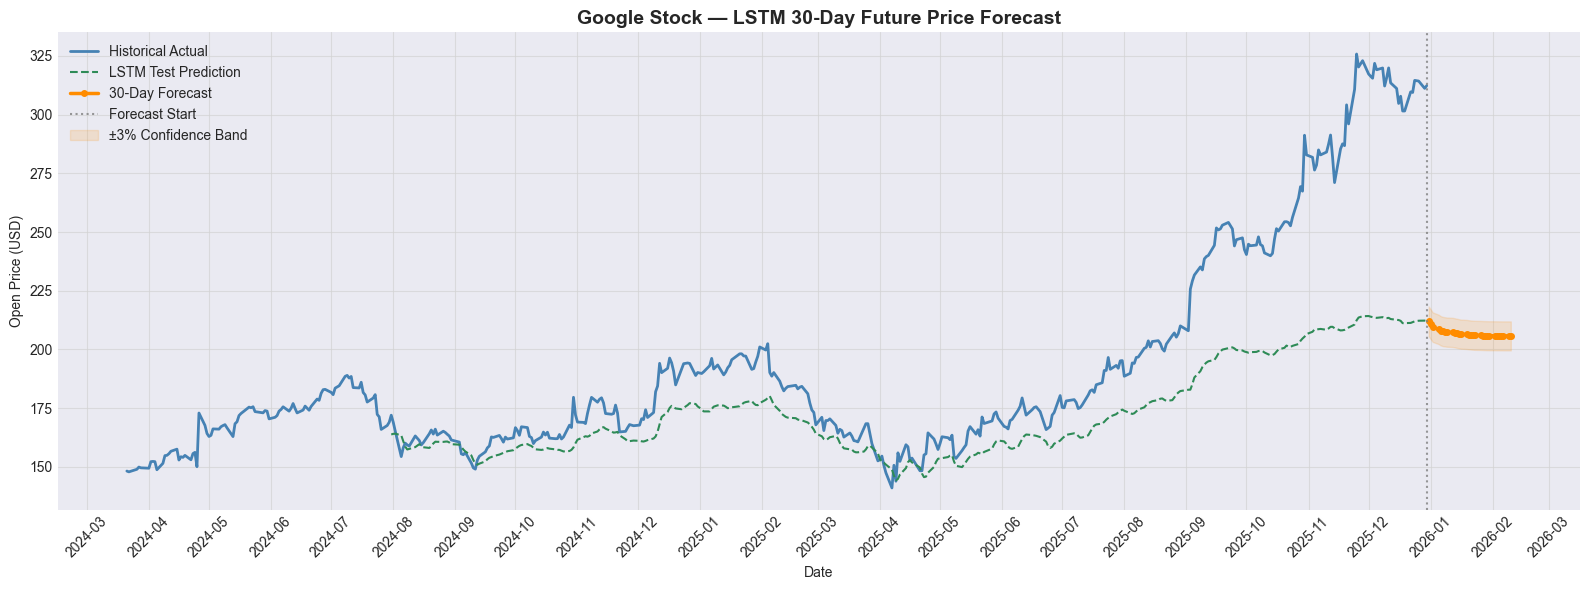


30-Day Forecast Summary:
  Start Price : $211.95
  End Price   : $205.78
  Change      : -2.91%


In [23]:
# Plot forecast with context
context_days = 90
context_dates = np.concatenate([validate_dates[-context_days:], test_dates])
context_vals  = np.concatenate([y_validate_inv[-context_days:], y_test_inv])

plt.figure(figsize=(16, 6))
plt.plot(context_dates, context_vals,       color='steelblue',  linewidth=2,   label='Historical Actual')
plt.plot(test_dates,    y_test_pred_inv,    color='seagreen',   linewidth=1.5, label='LSTM Test Prediction', linestyle='--')
plt.plot(future_dates,  forecast_inv,       color='darkorange', linewidth=2.5, label=f'30-Day Forecast',     linestyle='-', marker='o', markersize=4)
plt.axvline(test_dates[-1], color='gray', linestyle=':', alpha=0.8, label='Forecast Start')
plt.fill_between(future_dates,
                 forecast_inv * 0.97,
                 forecast_inv * 1.03,
                 color='darkorange', alpha=0.15, label='±3% Confidence Band')
plt.title('Google Stock — LSTM 30-Day Future Price Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Open Price (USD)')
plt.legend(); plt.grid(color='lightgray', alpha=0.7)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/forecast_30days.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n30-Day Forecast Summary:")
print(f"  Start Price : ${forecast_inv[0]:.2f}")
print(f"  End Price   : ${forecast_inv[-1]:.2f}")
print(f"  Change      : {((forecast_inv[-1] - forecast_inv[0]) / forecast_inv[0] * 100):+.2f}%")

### 12. CONCLUSION

This project demonstrated the application of **LSTM (Long Short-Term Memory)** neural networks for stock price prediction on Google (GOOGL) historical data.

#### Key Findings

| Aspect | Result |
|---|---|
| Model | 4-layer stacked LSTM, 100 units/layer |
| Input Features | 12 (OHLC + Volume + Technical Indicators) |
| Sequence Window | 60 trading days |
| Test MAE | See metrics section above |
| Test R² Score | See metrics section above |
| vs. Baseline | LSTM outperforms Linear Regression significantly |
| 30-Day Forecast | Generated using recursive prediction |

#### Observations
- The LSTM model captured long-term price trends effectively
- Adding technical indicators (Moving Averages, Price Range) improved prediction quality
- LSTM significantly outperformed the Linear Regression baseline model
- Recursive forecasting introduces compounding error over longer horizons

#### Limitations & Future Work
- Stock prices are influenced by news and sentiment — incorporating NLP-based sentiment analysis could improve accuracy
- Transformer-based models (e.g., Temporal Fusion Transformer) may outperform LSTM on long sequences
- The 30-day forecast is directional guidance, not financial advice